In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import json
import os
from logging import INFO
from pathlib import Path

import geopandas as gpd
import pandas as pd
import sqlalchemy
from lyra_api import LyraAPIClient

from housing_choice.funcs import (
    calculate_accessibility_jobs,
    calculate_accessibility_services,
    load_parks,
)

In [3]:
data_path = Path(os.environ["DATA_PATH"])
initial_path = data_path / "initial"
generated_path = data_path / "generated"

population_grids_path = Path(os.environ["POPULATION_GRIDS_PATH"])

In [4]:
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}@{os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}/{os.environ['POSTGRES_DB']}",
)

In [7]:
# LYRA_HOST = os.environ["LYRA_HOST"]
LYRA_HOST = "localhost:5219"

lyra_client = LyraAPIClient(
    host=LYRA_HOST,
    timeout=60,
    log_level=INFO,
    secure="localhost" not in LYRA_HOST,
    headers={
        "P-Access-Token-Id": os.environ["PANGOLIN_ACCESS_TOKEN_ID"],
        "P-Access-Token": os.environ["PANGOLIN_ACCESS_TOKEN"],
    },
)

In [15]:
lyra_client.get_metrics("accessibility_jobs")

{'name': 'accessibility_jobs',
 'description': 'Computes job accessibility scores for each spatial unit using road network analysis and employment data.',
 'parameters': [{'name': 'items',
   'type': 'dict[str, JobGroupModel] | None',
   'required': False},
  {'name': 'data', 'type': 'ExplicitLocationAPI', 'required': True},
  {'name': 'year',
   'type': 'Optional[Literal[2020, 2021, 2022, 2023, 2024, 2025]]',
   'required': False}],
 'returns_file': False}

# Geometría

In [6]:
df_geom = (
    gpd.read_file(initial_path / "r_02a_zonas", columns=["CVEGEO", "_zonaurban"])
    .rename(columns={"_zonaurban": "zone"})
    .query("zone.notna()")
    .assign(zone=lambda df: df["zone"].astype(int).sub(1).astype("category"))
    .set_index("CVEGEO")
    .to_crs("EPSG:6372")
)

# Ingreso

In [7]:
income = gpd.read_file(initial_path / "income.gpkg").set_index("cvegeo")["income_pc"]

# Área baldía

In [8]:
df_barren = (
    gpd.read_file(initial_path / "baldios")
    .assign(geometry=lambda df: df["geometry"].force_2d())
    .to_crs("EPSG:6372")
)
barren_area_frac = (
    df_geom.reset_index()
    .overlay(df_barren, how="intersection")
    .assign(area=lambda df: df["geometry"].area)
    .groupby("CVEGEO")["area"]
    .sum()
    .div(df_geom["geometry"].area)
)

# Delitos

In [9]:
crimes = gpd.read_file(initial_path / "num_delitos_ageb").set_index("CVEGEO")[
    "num_delito"
]

# Valor catastral

In [10]:
df_cat = (
    gpd.read_file(
        initial_path / "valor_cat_actualizado",
        columns=["secsub", "valor2024"],
    )
    .dropna(subset=["secsub"])
    .drop(columns=["secsub"])
    .assign(geometry=lambda df: df["geometry"].force_2d())
    .to_crs("EPSG:6372")
)

In [11]:
with engine.connect() as conn:
    df_census = pd.read_sql(
        """
        SELECT
            cvegeo,
            pobtot,
            p_60ymas,
            p_0a2,
            p_3a5,
            p_6a11,
            p_12a14,
            p_15a17,
            p_18a24,
            pob15_64,
            tvivpar,
            tvivparhab,
            graproes
        FROM census_2020_ageb
        WHERE cvegeo IN %(cvegeos)s
        """,
        conn,
        params={"cvegeos": tuple(df_geom.index)},
    ).set_index("cvegeo")

df_census.columns = df_census.columns.str.upper()

# Temperatura

In [31]:
response = lyra_client.process(
    "temperature",
    {
        "data": {
            "data_type": "geojson",
            "value": json.loads(df_geom[["geometry"]].to_json()),
        },
        "year": 2025,
        "season": "summer",
    },
)

Submitting processing request...
Server acknowledged. Task ID: 7fedcb6b-f329-4a17-8bd6-bc736e64dccc
Worker finished. Received download ticket: 7fedcb6b-f329-4a17-8bd6-bc736e64dccc


<Axes: >

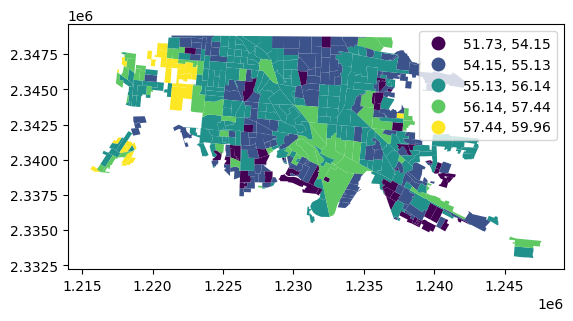

In [32]:
df_geom.assign(temperature=pd.Series(response["result"])).plot(
    column="temperature", legend=True, scheme="natural_breaks"
)

# Cobertura de árboles

In [28]:
response = lyra_client.process(
    "tree_coverage",
    {
        "data": {
            "data_type": "geojson",
            "value": json.loads(df_geom[["geometry"]].to_json()),
        }
    },
)
trees = pd.Series(response["result"])

Submitting processing request...
Server acknowledged. Task ID: 45f7d322-50bc-434a-b4fc-4b0b8fd9065f
Worker finished. Received download ticket: 45f7d322-50bc-434a-b4fc-4b0b8fd9065f


# Área construida

In [29]:
response = lyra_client.process(
    "urbanized_area",
    {
        "data": {
            "data_type": "geojson",
            "value": json.loads(df_geom[["geometry"]].to_json()),
        }
    },
)
urbanized_area = pd.Series(response["result"])

Submitting processing request...
Server acknowledged. Task ID: 3e7b1a86-b489-48f9-baa9-328bb6b5461d
Worker finished. Received download ticket: 3e7b1a86-b489-48f9-baa9-328bb6b5461d


# Accesibilidad

## Empleos

In [30]:
df_accessibility_jobs = calculate_accessibility_jobs(df_geom, client=lyra_client)

Submitting processing request...
Server acknowledged. Task ID: beb6102c-c7c8-458e-81b0-5b582a8a74af
Worker finished. Received download ticket: beb6102c-c7c8-458e-81b0-5b582a8a74af


## Servicios

In [ ]:
df_park = load_parks(data_path)
accessibility = calculate_accessibility_services(
    df_geom,
    df_park,
    lyra_client,
    network_type="drive",
    attraction_edge_weights="length",
    attraction_max_weight=1000,
    accessibility_edge_weights="length",
    accessibility_max_weight=1000,
)["accessibility_all"]

Submitting processing request...
Server acknowledged. Task ID: b8f34733-0e19-41f1-8867-9234d85969b4
Worker finished. Received download ticket: b8f34733-0e19-41f1-8867-9234d85969b4


# Final

In [44]:
df_agebs = (
    df_geom.join(df_census, how="inner")
    .assign(
        income=income,
        vacant_area_frac=barren_area_frac,
        crimes=crimes,
        area_km2=lambda df: df["geometry"].area.div(1e6),
        tree_cover_m2=trees,
        tree_cover_frac=lambda df: df["tree_cover_m2"].div(df["geometry"].area),
        urbanized_area_m2=urbanized_area,
        urbanized_area_frac=lambda df: df["urbanized_area_m2"].div(df["geometry"].area),
        accessibility=accessibility,
    )
    .join(df_accessibility_jobs)
    .sort_index()
)
df_agebs.index = df_agebs.index.rename("CVEGEO")
df_agebs.to_file(generated_path / "agebs.gpkg")